# MHAR 5-Minute Cleaning

**Purpose:** This notebook constructs two separate 5-minute volatility datasets for the EURO STOXX 50 from the raw intraday file `IntradaySummaries_.STOXX50E_19980220_20200809.csv`.

**Intraday: Excluding Overnight Returns**
- **RVD, RVW, RVM** — daily, weekly (5-day), and monthly (22-day) realized variance
- **logRVD, logRVW, logRVM** — log-transformed versions of realized variance
- **RVD_pos, RVD_neg** — positive and negative semivariance (for the SHAR model)
- **RD_neg, RW_neg, RM_neg** — negative return aggregates (for the LevHAR model)
- **RQ** — realized quarticity (for the HARQ model)

**Total (Intraday + Overnight): Including Overnight Returns**
- **RVD_tot, RVW_tot, RVM_tot** — daily, weekly (5-day), and monthly (22-day) realized variance
- **logRVD_tot, logRVW_tot, logRVM_tot** — log-transformed versions of realized variance
- **RVD_pos_tot, RVD_neg_tot** — positive and negative semivariance (for the SHAR model)
- **RD_neg_tot, RW_neg_tot, RM_neg_tot** — negative return aggregates (for the LevHAR model)
- **RQ_tot** — realized quarticity (for the HARQ model)

Relative to the original `MHAR_cleaning.ipynb`, the present notebook differs in two important ways. First, realized variance is computed from **5-minute** returns rather than 1-minute returns. Second, the total-daily specification does **not** simply add squared overnight returns to the intraday realized variance. Instead, it applies an overnight adjustment motivated by Hansen and Lunde's whole-day realized variance framework, so the overnight component is combined with the intraday measure in a more careful way.

## 1. Imports and Paths

We begin by importing the packages required for data handling and numerical calculations. The notebook uses only standard scientific Python libraries, and it keeps all path definitions explicit so the workflow is transparent and easy to reproduce.

In [5]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

raw_path = '/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Raw Data from Tobias Sichert/IntradaySummaries_.STOXX50E_19980220_20200809.csv'
save_dir = '/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets'
os.makedirs(save_dir, exist_ok=True)


## 2. Load the Raw Intraday Data

The raw file contains minute-by-minute price observations. As in the original MHAR cleaning notebook, we only need the timestamp and the last traded/index level in order to build realized-variance measures. All remaining columns are left out to keep the cleaning pipeline focused and memory-efficient.

In [8]:
df = pd.read_csv(raw_path, usecols=['Date-Time', 'Last'])
print(f'Raw shape: {df.shape}')
display(df.head())


Raw shape: (11817313, 2)


,Date-Time,Last
0,1998-02-20T12:47:00.000000000Z,NaN
1,1998-02-20T12:48:00.000000000Z,NaN
2,1998-02-20T12:49:00.000000000Z,NaN
3,1998-02-20T12:50:00.000000000Z,NaN
4,1998-02-20T12:51:00.000000000Z,NaN


## 3. Convert Timestamps and Restrict the Trading Window

We convert the original UTC timestamps into Central European time, remove weekends, and keep only the regular EURO STOXX 50 trading session from **09:00 to 17:30 CET/CEST**. This mirrors the original notebook and ensures that the intraday returns are computed only from regular exchange hours.

In [10]:
df['Date-Time'] = pd.to_datetime(df['Date-Time'], utc=True, errors='coerce')
df['Date-Time-CET'] = df['Date-Time'].dt.tz_convert('Europe/Berlin')

df = df[df['Date-Time-CET'].dt.weekday <= 4].copy()
df['Time_CET'] = df['Date-Time-CET'].dt.time

start_time = pd.Timestamp('09:00').time()
end_time = pd.Timestamp('17:30').time()

df = df[
    (df['Time_CET'] >= start_time) &
    (df['Time_CET'] <= end_time)
].copy()

print(f'Filtered shape: {df.shape}')
print(f'Date range after basic filtering: {df["Date-Time-CET"].min()} to {df["Date-Time-CET"].max()}')


Filtered shape: (2994684, 4)
Date range after basic filtering: 1998-02-20 13:47:00+01:00 to 2020-08-07 17:30:00+02:00


## 4. Remove the Incomplete First Day and Set the Time Index

The first calendar day in the sample, **1998-02-20**, is incomplete and is removed exactly as in the original cleaning notebook. We then sort the data and set the CET timestamp as the working index.

In [12]:
df = df[df['Date-Time-CET'].dt.date != pd.Timestamp('1998-02-20').date()].copy()
df = df.sort_values('Date-Time-CET').set_index('Date-Time-CET')

print(f'Shape after dropping the incomplete first day: {df.shape}')


Shape after dropping the incomplete first day: (2994460, 3)


## 5. Remove Days with Too Much Missing Data and Fill Remaining Gaps

As before, we remove any day with more than **50% missing bars** and then forward-fill and backward-fill the remaining missing prices within each day. This preserves days with only small interruptions while excluding days whose price record is too incomplete to support reliable realized-variance estimation. We do not consider there to be an obvious survivorship bias concern, given that the removals do not appear to be systematically concentrated in high-volatility periods. The pattern, observed through previous diagnostic checks, looks like data quality issues ratheer than stress-driven gaps. 

In [14]:
missing_per_day = df['Last'].isna().groupby(df.index.date).sum()
days_to_remove = missing_per_day[missing_per_day > 255].index

df = df[~pd.Series(df.index.date, index=df.index).isin(days_to_remove)].copy()

df['Last_filled'] = (
    df['Last']
    .groupby(df.index.date)
    .transform(lambda x: x.ffill().bfill())
)

print(f'Removed {len(days_to_remove)} days with more than 50% missing minute bars')
print(f'Remaining NaN after fill: {df["Last_filled"].isna().sum()}')


Removed 164 days with more than 50% missing minute bars
Remaining NaN after fill: 0


## 6. Remove the Known Corrupted Day

The date **1998-06-29** contains a data error in the original minute file. As in the earlier MHAR cleaning notebook, we remove this day before computing returns. This corruption stems from an unrealistic price spike in the intraday trading data. 

In [16]:
bad_day = pd.Timestamp('1998-06-29').date()
df = df[df.index.date != bad_day].copy()

print(f'Remaining trading days after removing the corrupted day: {len(np.unique(df.index.date))}')


Remaining trading days after removing the corrupted day: 5695


## 7. Construct the 5-Minute Price Grid

The raw file is still minute-by-minute, so we now convert it into a **5-minute sampling grid**. Because the cleaned minute series already contains one observation per minute during trading hours, the simplest and most transparent construction is to retain the timestamps at **09:00, 09:05, ..., 17:30**. This gives 103 prices and 102 returns on a full trading day. We verify that the resulting bar count is constant across the sample.

In [18]:
df_5m = df[df.index.minute % 5 == 0].copy()
df_5m['Date'] = pd.to_datetime(df_5m.index.date)

bars_per_day = df_5m['Last_filled'].groupby(df_5m['Date']).size()
print(bars_per_day.describe())
print('\nBar-count frequency:')
print(bars_per_day.value_counts().sort_index())

# Keep only complete 5-minute trading days.
complete_days = bars_per_day[bars_per_day == 103].index
df_5m = df_5m[df_5m['Date'].isin(complete_days)].copy()

print(f'\nNumber of complete 5-minute trading days: {len(complete_days)}')


count    5695.0
mean      103.0
std         0.0
min       103.0
25%       103.0
50%       103.0
75%       103.0
max       103.0
Name: Last_filled, dtype: float64

Bar-count frequency:
Last_filled
103    5695
Name: count, dtype: int64

Number of complete 5-minute trading days: 5695


## 8. Compute 5-Minute Log Returns

Let $P^{(5m)}_{t,i}$ denote the 5-minute price grid on day $t$. The intraday 5-minute log return is defined as

$$
r^{(5m)}_{t,i} = \log\left(P^{(5m)}_{t,i}
\right) - \log\left(P^{(5m)}_{t,i-1}
\right)
$$

where returns are computed **within each trading day only**. This means the first 5-minute observation of each day has a missing return by construction, and overnight returns are excluded at this stage.

In [20]:
df_5m['log_last_5m'] = np.log(df_5m['Last_filled'])
df_5m['r_5m'] = df_5m['log_last_5m'].groupby(df_5m['Date']).diff()

print(df_5m['r_5m'].describe())
print(f'\nMissing 5-minute returns (first bar of each day): {df_5m["r_5m"].isna().sum()}')


count    580890.000000
mean         -0.000002
std           0.001187
min          -0.075585
25%          -0.000456
50%           0.000000
75%           0.000466
max           0.050255
Name: r_5m, dtype: float64

Missing 5-minute returns (first bar of each day): 5695


## 9. Daily Open and Close Prices

The daily open and close prices are needed for the intraday return aggregates and for the overnight-adjusted total specification. We therefore store the first and last regular-hours price of each trading day from the cleaned minute data.

In [22]:
daily_open = df['Last_filled'].groupby(pd.to_datetime(df.index.date)).first()
daily_close = df['Last_filled'].groupby(pd.to_datetime(df.index.date)).last()

print('Daily open and close series created successfully.')
print(f'Date range: {daily_open.index.min().date()} to {daily_open.index.max().date()}')


Daily open and close series created successfully.
Date range: 1998-02-26 to 2020-08-07


## 10. Intraday-Only 5-Minute MHAR Features

We first build the **intraday-only** dataset. This version excludes overnight returns entirely and therefore uses only the variation accumulated during regular trading hours.

- `RVD`, `RVW`, `RVM` come from the 5-minute intraday realized variance and its 5-day and 22-day rolling averages.
- `RVD_pos` and `RVD_neg` use 5-minute positive and negative semivariance.
- `RD_neg`, `RW_neg`, and `RM_neg` are based on the **open-to-close** daily log return, where the weekly and monthly terms first average returns across the horizon and then apply the negative-part operator, consistent with LevHAR.
- `RQ` is the standard realized quarticity computed from 5-minute returns using the day-specific count of 5-minute returns.

In [24]:
# --- Core RV measures ---
RV_intraday = df_5m['r_5m'].pow(2).groupby(df_5m['Date']).sum()
RV_intraday.name = 'RVD'

# --- Verify bar count is always 102 ---
M_5m = df_5m['r_5m'].groupby(df_5m['Date']).count()
assert (M_5m == 102).all(), f"Unexpected bar counts found: {M_5m[M_5m != 102]}"

# --- Semivariance decomposition ---
RVD_pos = df_5m['r_5m'].where(df_5m['r_5m'] > 0, 0).pow(2).groupby(df_5m['Date']).sum()
RVD_neg = df_5m['r_5m'].where(df_5m['r_5m'] < 0, 0).pow(2).groupby(df_5m['Date']).sum()

# Verify semivariance identity: RVD_pos + RVD_neg == RVD
residual = (RVD_pos + RVD_neg - RV_intraday).abs()
assert residual.max() < 1e-10, f"Semivariance decomposition error: max residual = {residual.max()}"

# --- Intraday (open-to-close) return and LevHAR negative-return aggregates ---
intraday_return = np.log(daily_close / daily_open)
intraday_return = intraday_return.loc[RV_intraday.index]
intraday_return_neg = intraday_return.clip(upper=0)
intraday_return_w = intraday_return.rolling(window=5).mean()
intraday_return_m = intraday_return.rolling(window=22).mean()
intraday_return_w_neg = intraday_return_w.clip(upper=0)
intraday_return_m_neg = intraday_return_m.clip(upper=0)

# --- Realized quarticity ---
# Implements equation (11) from Christensen, Siggaard, and Veliyev (2023):
# RQ_t = (n/3) * sum(r^4), where n = 102 for the 5-minute EURO STOXX 50 grid
RQ_intraday = (M_5m / 3) * df_5m['r_5m'].pow(4).groupby(df_5m['Date']).sum()

# --- Assemble dataframe ---
MHAR_5m_intraday = pd.DataFrame({
    'RVD': RV_intraday,
    'RVW': RV_intraday.rolling(window=5).mean(),
    'RVM': RV_intraday.rolling(window=22).mean(),
    'logRVD': np.log(RV_intraday),
    # logRVW and logRVM follow equation (6): log of the rolling mean of realized variance
    'logRVW': np.log(RV_intraday.rolling(window=5).mean()),
    'logRVM': np.log(RV_intraday.rolling(window=22).mean()),
    'RVD_pos': RVD_pos,
    'RVD_neg': RVD_neg,
    'RD_neg': intraday_return_neg,
    'RW_neg': intraday_return_w_neg,
    'RM_neg': intraday_return_m_neg,
    'RQ': RQ_intraday,
})

# --- Reorder columns ---
MHAR_5m_intraday = MHAR_5m_intraday[[
    'RVD', 'RVW', 'RVM',
    'logRVD', 'logRVW', 'logRVM',
    'RVD_pos', 'RVD_neg',
    'RD_neg', 'RW_neg', 'RM_neg',
    'RQ'
]]

# --- Diagnostics before dropna ---
print(f'Rows before dropna: {len(MHAR_5m_intraday)}')
print(f'Rows lost to rolling window NaNs: {MHAR_5m_intraday.isna().any(axis=1).sum()}')
# Expected: exactly 21 rows lost (first 21 days cannot form a complete 22-day RVM window)

# --- Drop NaNs ---
MHAR_5m_intraday = MHAR_5m_intraday.dropna()
print(f'Rows after dropna: {len(MHAR_5m_intraday)}')

# --- Final diagnostics ---
print(f'\nIntraday-only dataframe shape: {MHAR_5m_intraday.shape}')
print(f'Date range: {MHAR_5m_intraday.index.min().date()} to {MHAR_5m_intraday.index.max().date()}')
display(MHAR_5m_intraday.describe())
display(MHAR_5m_intraday.head())

Rows before dropna: 5695
Rows lost to rolling window NaNs: 21
Rows after dropna: 5674

Intraday-only dataframe shape: (5674, 12)
Date range: 1998-03-30 to 2020-08-07


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,RM_neg,RQ
count,5.674000e+03,5674.000000,5674.000000,5674.000000,5674.000000,5674.000000,5.674000e+03,5.674000e+03,5674.000000,5674.000000,5674.000000,5.674000e+03
mean,1.441171e-04,0.000144,0.000144,-9.438054,-9.347090,-9.282893,6.888696e-05,7.523011e-05,-0.004425,-0.002088,-0.001036,6.295623e-07
std,2.853109e-04,0.000228,0.000190,1.026422,0.917884,0.863076,1.215302e-04,1.875878e-04,0.008107,0.003853,0.001952,1.918050e-05
min,9.275621e-09,0.000008,0.000011,-18.495876,-11.724458,-11.407865,3.158397e-09,6.117225e-09,-0.105367,-0.054144,-0.019078,2.146797e-16
25%,4.009301e-05,0.000045,0.000049,-10.124308,-10.006036,-9.933167,1.935088e-05,1.791574e-05,-0.005753,-0.002911,-0.001374,2.610694e-09
50%,7.606027e-05,0.000081,0.000085,-9.483985,-9.417127,-9.372524,3.666609e-05,3.638533e-05,0.000000,0.000000,0.000000,1.000827e-08
75%,1.501459e-04,0.000149,0.000154,-8.803903,-8.808409,-8.781348,7.194858e-05,7.667447e-05,0.000000,0.000000,0.000000,4.107786e-08
max,9.794934e-03,0.003475,0.002045,-4.625890,-5.662199,-6.192582,2.755776e-03,7.626905e-03,0.000000,0.000000,0.000000,1.129754e-03


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,RM_neg,RQ
Date,,,,,,,,,,,,
1998-03-30,0.000071,0.000060,0.000064,-9.550019,-9.727785,-9.653726,0.000032,0.000039,-0.003233,0.0,0.0,7.017334e-09
1998-03-31,0.000053,0.000058,0.000064,-9.844566,-9.746576,-9.649957,0.000026,0.000027,0.000000,0.0,0.0,4.848406e-09
1998-04-01,0.000065,0.000063,0.000064,-9.638335,-9.676560,-9.652131,0.000043,0.000022,0.000000,0.0,0.0,4.904402e-09
1998-04-02,0.000045,0.000059,0.000064,-10.009022,-9.730652,-9.656873,0.000030,0.000015,0.000000,0.0,0.0,3.868715e-09
1998-04-03,0.000077,0.000062,0.000065,-9.473854,-9.684375,-9.637785,0.000050,0.000027,0.000000,0.0,0.0,8.732961e-09


## 11. Overnight Adjustment for the Total Daily Measure

For the second dataset, we want a **whole-day** realized variance measure that includes overnight information. Rather than simply adding squared overnight return to intraday realized variance, we follow the **Hansen-Lunde idea** of combining the two components through an adjusted linear combination.

Let

$$
r^{ON}_t = \log\left(\frac{P^{open}_t}{P^{close}_{t-1}}\right),
$$

and let $RV^{intra}_t$ denote the intraday 5-minute realized variance. We then define the adjusted whole-day measure as

$$
RV^{tot}_t = \omega_1 (r^{ON}_t)^2 + \omega_2 RV^{intra}_t,
$$

where the weights are estimated from the sample moments of the overnight and intraday variance components. In the notebook below, we use the standard sample-moment implementation of this Hansen-Lunde style adjustment so that the overnight contribution is not mechanically forced to enter with weight one.

In [26]:
overnight_return = np.log(daily_open / daily_close.shift(1))
overnight_sq = overnight_return.pow(2)

overnight_df = pd.DataFrame({
    'RV_intraday_5m': RV_intraday,
    'overnight_return': overnight_return,
    'RV_overnight_raw': overnight_sq,
}).dropna()

mu1 = overnight_df['RV_overnight_raw'].mean()
mu2 = overnight_df['RV_intraday_5m'].mean()
mu0 = (overnight_df['RV_overnight_raw'] + overnight_df['RV_intraday_5m']).mean()
eta1 = overnight_df['RV_overnight_raw'].var(ddof=0)
eta2 = overnight_df['RV_intraday_5m'].var(ddof=0)
eta12 = np.cov(
    overnight_df['RV_overnight_raw'],
    overnight_df['RV_intraday_5m'],
    ddof=0
)[0, 1]

denom = mu2**2 * eta1 + mu1**2 * eta2 - 2 * mu1 * mu2 * eta12
if not np.isfinite(denom) or abs(denom) < 1e-25:
    raise ValueError('Hansen-Lunde denominator is not well defined.')

phi = (mu2**2 * eta1 - mu1 * mu2 * eta12) / denom
omega_1 = (1 - phi) * mu0 / mu1
omega_2 = phi * mu0 / mu2

print('Estimated overnight-adjustment weights:')
print(f'  omega_1 (overnight weight): {omega_1:.6f}')
print(f'  omega_2 (intraday weight):  {omega_2:.6f}')
print(f'  Mean-matching check:        {omega_1 * mu1 + omega_2 * mu2:.6e}')

overnight_df['RVD_tot'] = (
    omega_1 * overnight_df['RV_overnight_raw'] +
    omega_2 * overnight_df['RV_intraday_5m']
)

overnight_df['overnight_component_adj'] = omega_1 * overnight_df['RV_overnight_raw']
overnight_df['intraday_component_adj'] = omega_2 * overnight_df['RV_intraday_5m']


Estimated overnight-adjustment weights:
  omega_1 (overnight weight): 2.207014
  omega_2 (intraday weight):  0.746907
  Mean-matching check:        1.739986e-04


## 12. Build the Total (Intraday + Overnight) 5-Minute Features

The adjusted total dataset is built from the overnight-adjusted whole-day realized variance. To keep the decomposition coherent:

- `RVD_pos_tot` and `RVD_neg_tot` use the **weighted intraday semivariances** and allocate the weighted overnight variance contribution according to the sign of the overnight return.
- `RD_neg_tot`, `RW_neg_tot`, and `RM_neg_tot` are based on the **close-to-close** daily log return, where the weekly and monthly terms first average returns across the horizon and then apply the negative-part operator, because this return naturally includes the overnight component.
- `RQ_tot` is constructed as a practical extension of the intraday quarticity by applying the same overnight-adjustment weights to the fourth-moment contributions. The paper's direct adjustment concerns realized variance, so this quarticity extension should be viewed as a transparent thesis implementation choice rather than a verbatim formula from the overnight-adjustment paper.

In [28]:
# --- Weighted semivariance components ---
intraday_pos_weighted = omega_2 * RVD_pos.loc[overnight_df.index]
intraday_neg_weighted = omega_2 * RVD_neg.loc[overnight_df.index]
overnight_component_adj = overnight_df['overnight_component_adj']
overnight_pos_adj = overnight_component_adj.where(overnight_df['overnight_return'] > 0, 0.0)
overnight_neg_adj = overnight_component_adj.where(overnight_df['overnight_return'] < 0, 0.0)

# --- Verify semivariance identity ---
# (omega_2 * RVD_pos + omega_2 * RVD_neg) + omega_1 * overnight_sq should equal RVD_tot
semivar_sum = intraday_pos_weighted + intraday_neg_weighted + overnight_component_adj
residual_check = (semivar_sum - overnight_df['RVD_tot']).abs()
assert residual_check.max() < 1e-10, \
    f"Pre-assembly semivariance check failed: max residual = {residual_check.max()}"

# --- Close-to-close returns for the total specification ---
close_to_close_return = np.log(daily_close / daily_close.shift(1)).loc[overnight_df.index]
close_to_close_return_neg = close_to_close_return.clip(upper=0)
close_to_close_return_w = close_to_close_return.rolling(window=5).mean()
close_to_close_return_m = close_to_close_return.rolling(window=22).mean()
close_to_close_return_w_neg = close_to_close_return_w.clip(upper=0)
close_to_close_return_m_neg = close_to_close_return_m.clip(upper=0)

# --- Quarticity extension for the total specification ---
# RQ_tot = omega_2^2 * RQ_intraday + omega_1^2 * (r_overnight)^4
# This is an approximation: cross-terms are omitted and squared variance weights
# are used as proxies for quarticity scaling weights.
RQ_tot = (
    (omega_2 ** 2) * RQ_intraday.loc[overnight_df.index] +
    (omega_1 ** 2) * overnight_df['overnight_return'].pow(4)
)

# --- Assemble dataframe ---
MHAR_5m_total = pd.DataFrame({
    'RVD_tot': overnight_df['RVD_tot'],
    'RVW_tot': overnight_df['RVD_tot'].rolling(window=5).mean(),
    'RVM_tot': overnight_df['RVD_tot'].rolling(window=22).mean(),
    # logRVW_tot and logRVM_tot follow the same convention as the intraday specification:
    # log of the rolling mean of realized variance, consistent with LogHAR equation (6).
    'logRVD_tot': np.log(overnight_df['RVD_tot']),
    'logRVW_tot': np.log(overnight_df['RVD_tot'].rolling(window=5).mean()),
    'logRVM_tot': np.log(overnight_df['RVD_tot'].rolling(window=22).mean()),
    'RVD_pos_tot': intraday_pos_weighted + overnight_pos_adj,
    'RVD_neg_tot': intraday_neg_weighted + overnight_neg_adj,
    'RD_neg_tot': close_to_close_return_neg,
    'RW_neg_tot': close_to_close_return_w_neg,
    'RM_neg_tot': close_to_close_return_m_neg,
    'RQ_tot': RQ_tot,
})

# --- Reorder columns ---
MHAR_5m_total = MHAR_5m_total[[
    'RVD_tot', 'RVW_tot', 'RVM_tot',
    'logRVD_tot', 'logRVW_tot', 'logRVM_tot',
    'RVD_pos_tot', 'RVD_neg_tot',
    'RD_neg_tot', 'RW_neg_tot', 'RM_neg_tot',
    'RQ_tot'
]]

# --- Verify post-assembly semivariance identity ---
residual_tot = (
    MHAR_5m_total['RVD_pos_tot'] +
    MHAR_5m_total['RVD_neg_tot'] -
    MHAR_5m_total['RVD_tot']
).abs()
assert residual_tot.max() < 1e-10, \
    f"Post-assembly semivariance decomposition error: max residual = {residual_tot.max()}"

# --- Verify no negative RV values ---
rv_cols = ['RVD_tot', 'RVW_tot', 'RVM_tot', 'RVD_pos_tot', 'RVD_neg_tot', 'RQ_tot']
for col in rv_cols:
    min_val = MHAR_5m_total[col].min()
    assert min_val >= 0, f"Negative RV values found in {col}: min = {min_val}"

# --- Diagnostics before dropna ---
print(f'Rows before dropna: {len(MHAR_5m_total)}')
print(f'Rows lost to rolling window NaNs: {MHAR_5m_total.isna().any(axis=1).sum()}')
# Expected: exactly 21 rows lost (first 21 days cannot form a complete 22-day RVM window)

# --- Drop NaNs ---
MHAR_5m_total = MHAR_5m_total.dropna()
print(f'Rows after dropna: {len(MHAR_5m_total)}')

# --- Verify total RV is on average larger than intraday-only RV ---
mean_rv_intraday = MHAR_5m_intraday['RVD'].mean()
mean_rv_total = MHAR_5m_total['RVD_tot'].mean()
print(f'\nMean RVD intraday:      {mean_rv_intraday:.6e}')
print(f'Mean RVD total:         {mean_rv_total:.6e}')
assert mean_rv_total > mean_rv_intraday, \
    "Total RV should on average exceed intraday-only RV."

# --- Final diagnostics ---
print(f'\nTotal adjusted dataframe shape: {MHAR_5m_total.shape}')
print(f'Date range: {MHAR_5m_total.index.min().date()} to {MHAR_5m_total.index.max().date()}')
display(MHAR_5m_total.describe())
display(MHAR_5m_total.head())


Rows before dropna: 5694
Rows lost to rolling window NaNs: 21
Rows after dropna: 5673

Mean RVD intraday:      1.441171e-04
Mean RVD total:         1.743636e-04

Total adjusted dataframe shape: (5673, 12)
Date range: 1998-03-31 to 2020-08-07


,RVD_tot,RVW_tot,RVM_tot,logRVD_tot,logRVW_tot,logRVM_tot,RVD_pos_tot,RVD_neg_tot,RD_neg_tot,RW_neg_tot,RM_neg_tot,RQ_tot
count,5.673000e+03,5673.000000,5673.000000,5673.000000,5673.000000,5673.000000,5.673000e+03,5.673000e+03,5673.000000,5673.000000,5673.000000,5.673000e+03
mean,1.743636e-04,0.000174,0.000174,-9.272106,-9.121985,-9.045841,8.596218e-05,8.840145e-05,-0.005034,-0.002259,-0.001038,3.795165e-07
std,3.031826e-04,0.000245,0.000210,1.059797,0.901204,0.820343,1.669775e-04,2.012875e-04,0.009268,0.004185,0.001996,1.070790e-05
min,4.687350e-07,0.000007,0.000016,-14.573228,-11.827246,-11.049635,4.290146e-07,4.568999e-09,-0.120054,-0.054131,-0.021635,1.954215e-13
25%,4.600442e-05,0.000057,0.000064,-9.986773,-9.778955,-9.652960,1.972261e-05,1.605997e-05,-0.006617,-0.003119,-0.001348,2.217565e-09
50%,9.102233e-05,0.000102,0.000110,-9.304406,-9.194014,-9.110728,4.021940e-05,3.583152e-05,0.000000,0.000000,0.000000,8.367918e-09
75%,1.826034e-04,0.000186,0.000179,-8.608194,-8.587523,-8.629571,8.557858e-05,8.459113e-05,0.000000,0.000000,0.000000,3.386532e-08
max,7.329728e-03,0.003659,0.002165,-4.915817,-5.610580,-6.135409,3.210478e-03,5.710411e-03,0.000000,0.000000,0.000000,6.302564e-04


,RVD_tot,RVW_tot,RVM_tot,logRVD_tot,logRVW_tot,logRVM_tot,RVD_pos_tot,RVD_neg_tot,RD_neg_tot,RW_neg_tot,RM_neg_tot,RQ_tot
1998-03-31,0.000045,0.000135,0.000074,-10.003207,-8.912700,-9.511036,0.000025,0.000020,0.0,0.0,0.0,2.736622e-09
1998-04-01,0.000051,0.000134,0.000074,-9.875875,-8.918303,-9.515707,0.000035,0.000017,0.0,0.0,0.0,2.743394e-09
1998-04-02,0.000035,0.000129,0.000073,-10.265676,-8.953749,-9.518729,0.000024,0.000011,0.0,0.0,0.0,2.159688e-09
1998-04-03,0.000061,0.000050,0.000074,-9.698709,-9.906003,-9.507560,0.000041,0.000020,0.0,0.0,0.0,4.887656e-09
1998-04-06,0.000118,0.000062,0.000077,-9.041205,-9.684343,-9.472731,0.000110,0.000009,0.0,0.0,0.0,1.038978e-08


## 13. Summary Tables

To make the two datasets easy to inspect, we create one compact summary-statistics table for the intraday-only measure and one for the overnight-adjusted total measure. The realized-variance variables are converted to annualized volatility percentages for readability, while quarticity is scaled by $10^6$ as in the earlier notebook.

In [30]:
def build_summary_table(df_features, total=False):
    if total:
        display_df = pd.DataFrame({
            'RVD_tot': np.sqrt(df_features['RVD_tot'] * 252) * 100,
            'RVW_tot': np.sqrt(df_features['RVW_tot'] * 252) * 100,
            'RVM_tot': np.sqrt(df_features['RVM_tot'] * 252) * 100,
            'logRVD_tot': df_features['logRVD_tot'],
            'logRVW_tot': df_features['logRVW_tot'],
            'logRVM_tot': df_features['logRVM_tot'],
            'RVD_pos_tot': np.sqrt(df_features['RVD_pos_tot'] * 252) * 100,
            'RVD_neg_tot': np.sqrt(df_features['RVD_neg_tot'] * 252) * 100,
            'RD_neg_tot': df_features['RD_neg_tot'] * 100,
            'RW_neg_tot': df_features['RW_neg_tot'] * 100,
            'RM_neg_tot': df_features['RM_neg_tot'] * 100,
            'RQ_tot': df_features['RQ_tot'] * 1e6,
        })
    else:
        display_df = pd.DataFrame({
            'RVD': np.sqrt(df_features['RVD'] * 252) * 100,
            'RVW': np.sqrt(df_features['RVW'] * 252) * 100,
            'RVM': np.sqrt(df_features['RVM'] * 252) * 100,
            'logRVD': df_features['logRVD'],
            'logRVW': df_features['logRVW'],
            'logRVM': df_features['logRVM'],
            'RVD_pos': np.sqrt(df_features['RVD_pos'] * 252) * 100,
            'RVD_neg': np.sqrt(df_features['RVD_neg'] * 252) * 100,
            'RD_neg': df_features['RD_neg'] * 100,
            'RW_neg': df_features['RW_neg'] * 100,
            'RM_neg': df_features['RM_neg'] * 100,
            'RQ': df_features['RQ'] * 1e6,
        })

    summary = pd.DataFrame({
        'Observations': display_df.count(),
        'Mean': display_df.mean(),
        'Median': display_df.median(),
        'Std. Dev.': display_df.std(),
        'Skewness': display_df.skew(),
        'Exc. Kurtosis': display_df.kurt(),
        'Minimum': display_df.min(),
        'Maximum': display_df.max(),
    }).T.round(4)
    return summary

summary_intraday = build_summary_table(MHAR_5m_intraday, total=False)
summary_total = build_summary_table(MHAR_5m_total, total=True)

print('Intraday-only 5-minute summary statistics:')
display(summary_intraday)

print('\nOvernight-adjusted total 5-minute summary statistics:')
display(summary_total)


Intraday-only 5-minute summary statistics:


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,RM_neg,RQ
Observations,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000,5674.0000
Mean,16.2531,16.6311,16.9436,-9.4381,-9.3471,-9.2829,11.2943,11.4446,-0.4425,-0.2088,-0.1036,0.6296
Median,13.8446,14.3152,14.6380,-9.4840,-9.4171,-9.3725,9.6124,9.5755,0.0000,0.0000,0.0000,0.0100
Std. Dev.,9.9513,9.3031,8.7131,1.0264,0.9179,0.8631,6.7853,7.6559,0.8107,0.3853,0.1952,19.1805
Skewness,3.1090,2.5724,2.1091,0.0550,0.5521,0.6082,2.7165,3.7238,-3.2945,-3.7184,-3.3960,51.2316
Exc. Kurtosis,19.7604,10.7348,6.2697,2.4419,0.4230,0.2501,13.0990,31.8855,17.2510,23.8372,16.2511,2771.8021
Minimum,0.1529,4.5161,5.2907,-18.4959,-11.7245,-11.4079,0.0892,0.1242,-10.5367,-5.4144,-1.9078,0.0000
Maximum,157.1090,93.5771,71.7791,-4.6259,-5.6622,-6.1926,83.3340,138.6355,0.0000,0.0000,0.0000,1129.7537



Overnight-adjusted total 5-minute summary statistics:


,RVD_tot,RVW_tot,RVM_tot,logRVD_tot,logRVW_tot,logRVM_tot,RVD_pos_tot,RVD_neg_tot,RD_neg_tot,RW_neg_tot,RM_neg_tot,RQ_tot
Observations,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000,5673.0000
Mean,17.8258,18.5076,18.8809,-9.2721,-9.1220,-9.0458,12.2442,11.9739,-0.5034,-0.2259,-0.1038,0.3795
Median,15.1452,16.0046,16.6852,-9.3044,-9.1940,-9.1107,10.0674,9.5024,0.0000,0.0000,0.0000,0.0084
Std. Dev.,11.0300,9.8453,9.0928,1.0598,0.9012,0.8203,8.1680,8.9113,0.9268,0.4185,0.1996,10.7079
Skewness,2.5018,2.2094,1.9619,0.2104,0.4940,0.6098,2.7103,2.9782,-3.2568,-3.4169,-3.3693,51.1287
Exc. Kurtosis,10.8363,7.8037,5.4462,0.4731,0.2161,0.1752,12.5596,15.5958,16.2600,19.7014,17.1890,2763.8773
Minimum,1.0868,4.2899,6.3285,-14.5732,-11.8272,-11.0496,1.0398,0.1073,-12.0054,-5.4131,-2.1635,0.0000
Maximum,135.9077,96.0237,73.8606,-4.9158,-5.6106,-6.1354,89.9467,119.9593,0.0000,0.0000,0.0000,630.2564


## 14. Save the Two Final Dataframes

Finally, we save the two cleaned datasets as separate CSV files. This keeps the intraday-only specification and the overnight-adjusted total specification distinct and ready for later modeling work.

In [32]:
intraday_path = os.path.join(save_dir, 'MHAR_5min_intraday.csv')
total_path = os.path.join(save_dir, 'MHAR_5min_total_adjusted.csv')

MHAR_5m_intraday.to_csv(intraday_path)
MHAR_5m_total.to_csv(total_path)

print(f'Intraday-only dataset saved to: {intraday_path}')
print(f'Total adjusted dataset saved to: {total_path}')


Intraday-only dataset saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MHAR_5min_intraday.csv
Total adjusted dataset saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MHAR_5min_total_adjusted.csv


## 15. Final Verification

We reload the saved files to verify that the shapes, date ranges, and column names match the intended design.

In [34]:
intraday_check = pd.read_csv(intraday_path, index_col=0, parse_dates=True)
total_check = pd.read_csv(total_path, index_col=0, parse_dates=True)

print('Intraday-only verification:')
print(f'  Shape: {intraday_check.shape}')
print(f'  Date range: {intraday_check.index.min().date()} to {intraday_check.index.max().date()}')
print(f'  Columns: {intraday_check.columns.tolist()}')
print(f'  NaN values: {intraday_check.isna().sum().sum()}')

print('\nTotal adjusted verification:')
print(f'  Shape: {total_check.shape}')
print(f'  Date range: {total_check.index.min().date()} to {total_check.index.max().date()}')
print(f'  Columns: {total_check.columns.tolist()}')
print(f'  NaN values: {total_check.isna().sum().sum()}')


Intraday-only verification:
  Shape: (5674, 12)
  Date range: 1998-03-30 to 2020-08-07
  Columns: ['RVD', 'RVW', 'RVM', 'logRVD', 'logRVW', 'logRVM', 'RVD_pos', 'RVD_neg', 'RD_neg', 'RW_neg', 'RM_neg', 'RQ']
  NaN values: 0

Total adjusted verification:
  Shape: (5673, 12)
  Date range: 1998-03-31 to 2020-08-07
  Columns: ['RVD_tot', 'RVW_tot', 'RVM_tot', 'logRVD_tot', 'logRVW_tot', 'logRVM_tot', 'RVD_pos_tot', 'RVD_neg_tot', 'RD_neg_tot', 'RW_neg_tot', 'RM_neg_tot', 'RQ_tot']
  NaN values: 0


## 16. Illustrative Line Charts and Weight Interpretation

To visualize the two daily measures directly, we add one line chart for the intraday-only realized variance `RVD` and one for the overnight-adjusted total realized variance `RVD_tot`. We also report the **average weighted contribution** of the overnight and intraday components in the adjusted total measure. This is helpful because the Hansen-Lunde weights should not be interpreted as simple percentage shares on their own; the economically relevant object is the weighted contribution `omega_1 E[(r_t^{ON})^2]` versus `omega_2 E[RV_t^{intra}]`.

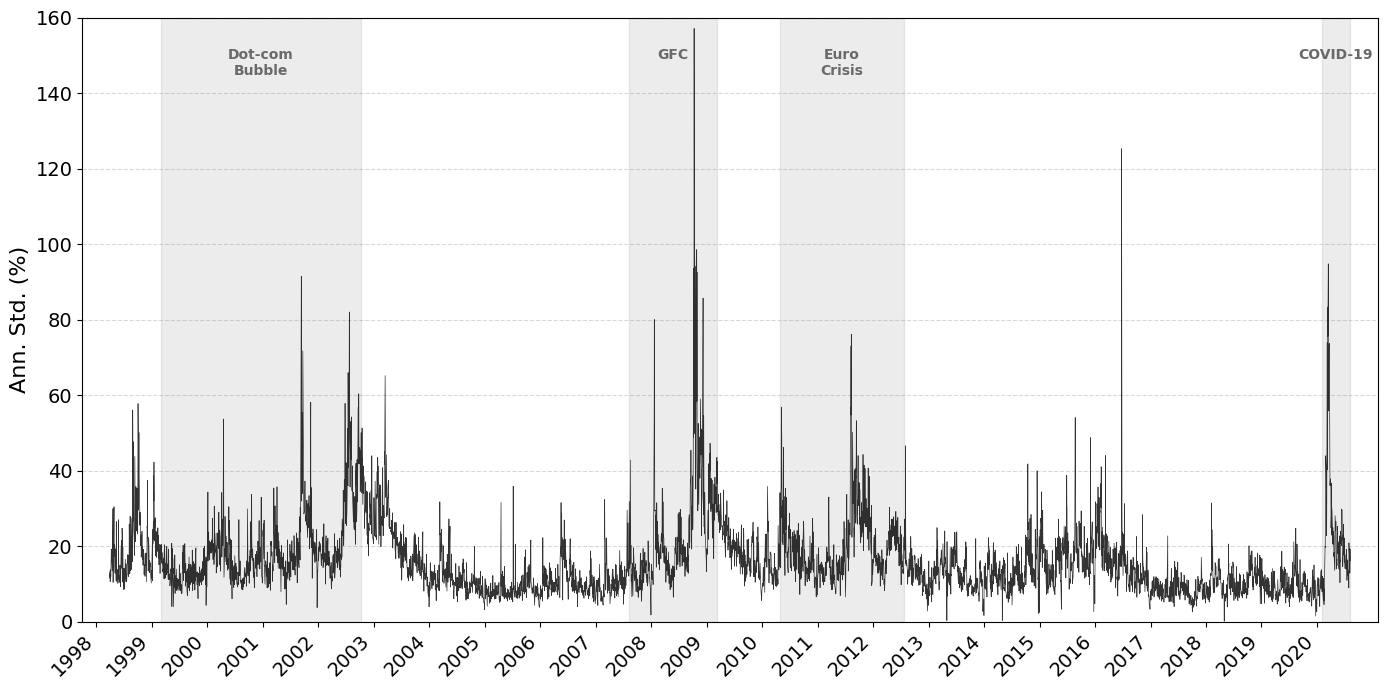

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 7))

# Convert RVD to annualized volatility for plotting
rv_ann = np.sqrt(MHAR_5m_intraday['RVD'] * 252) * 100

# Plot RVD
ax.plot(MHAR_5m_intraday.index, rv_ann, color="black", linewidth=0.5, alpha=0.8)
ax.set_ylabel("Ann. Std. (%)", fontsize=16)

# Set y-axis limit to 160 to accommodate crisis spikes
ax.set_ylim(0, 160)

# Symmetric padding
start_data = pd.Timestamp("1998-03-30")
end_data   = pd.Timestamp("2020-08-07")
padding    = pd.DateOffset(months=6)
ax.set_xlim(start_data - padding, end_data + padding)

# Format x-axis — only show ticks between 1998 and 2020 inclusive
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Remove out-of-range tick labels
ax.set_xticks([t for t in ax.get_xticks()
               if mdates.date2num(pd.Timestamp("1998-01-01")) <= t
               <= mdates.date2num(pd.Timestamp("2020-12-31"))])
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)

# Add shaded regions for major crisis periods
crisis_periods = [
    ("1999-03-01", "2002-10-09", "Dot-com\nBubble"),
    ("2007-08-09", "2009-03-09", "GFC"),
    ("2010-04-27", "2012-07-26", "Euro\nCrisis"),
    ("2020-02-01", "2020-08-07", "COVID-19"),
]

for start, end, label in crisis_periods:
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        alpha=0.15,
        color="gray"
    )
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(
        mid, ax.get_ylim()[1] * 0.95,
        label,
        fontsize=10,
        ha="center",
        va="top",
        color="dimgray",
        fontweight="bold"
    )

ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig(
    "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Figures/Data/RV_5min_intraday_time_series.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()